In [10]:
import matplotlib.pyplot as plt 
import agama
import numpy as np 
import hunter2024mwmodel
import barframe
agama.setUnits(length=1,mass=1,velocity=1)
import explore_hunter_bar_frame_sos as ehbfs
import multiprocessing as mp 
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{txfonts}",
})

In [2]:
# initialize the model in a different cell, longer start up 
pot = hunter2024mwmodel.mw_model()
omega = -37.5

In [ ]:
jacobi_frac = 24/25
jac_fracs = [3/4, 4/5, 5/6, 9/10, 49/50]
n = 10
jac_fracs = [i/(i+1) for i in range(3,n)]
higher_order = [19/20,29/30,39/40,49/50,99/100]
for hh in higher_order:
    jac_fracs.append(hh)

NN1 = 9
NN2 = 14
NN3 = 14
colors = np.random.random((NN1+NN2+NN3,3))

for cc,jacobi_frac in enumerate(jac_fracs):
    integration_time = 3
    x_l1 = barframe.xL1(pot, omega)
    e_l1 = barframe.pot_eff(pot, omega, np.array([x_l1, 0.0, 0.0]))
    e_0 = barframe.pot_eff(pot, omega, np.array([0.0, 0.0, 0.0]))
    ej = jacobi_frac * (e_l1 - e_0) + e_0
    xmax = barframe.xmaximum_within_bar(pot,omega,ej)
    vx_max_x0 = barframe.vx_zero_velocity_curve(0, pot, omega, ej)
    tolerence = 1e-2
    vxs0 = np.linspace(-(1-tolerence)*vx_max_x0, (1-tolerence)*vx_max_x0, NN1)
    args = [
        dict(
            pot=pot,
            omega=omega,
            ej=ej,
            x=0.0,
            vx=vx,
            integration_time=integration_time,
            trajsize=int(1e4),
            orbit_tail_fraction=0.10,
        )
        for vx in vxs0
    ]
    # x2 orbits 
    x1xs=np.linspace(0,(1-tolerence)*xmax,NN2)
    for x in x1xs:
        args.append(dict(
            pot=pot,
            omega=omega,
            ej=ej,
            x=x,
            vx=0,
            integration_time=integration_time,
            trajsize=int(1e4),
            orbit_tail_fraction=0.10,))

    # now add the good bar ones last 
    # x2 orbits 
    x1xs=np.linspace(0,-(1-tolerence)*xmax,NN3)
    for x in x1xs:
        args.append(dict(
            pot=pot,
            omega=omega,
            ej=ej,
            x=x,
            vx=0,
            integration_time=2*integration_time,
            trajsize=int(1e4),
            orbit_tail_fraction=0.10,))

    results = []
    skipped = 0
    for arg in args:
        try:
            results.append(ehbfs.integrate_section_orbit_kwargs(arg))
        except ValueError as exc:
            skipped += 1
            print(f"Skipping invalid orbit seed x={arg['x']:.6g}, vx={arg['vx']:.6g}: {exc}")

    print(f"Computed {len(results)} orbits, skipped {skipped} invalid seeds.")

    xmax, xs, vxs, xs_poly, vxs_poly=ehbfs.make_zvc(ej,pot,omega)

    

    fig, (ax_orbit, ax_sos) = plt.subplots(1, 2, figsize=(10, 4))
    for i,result in enumerate(results):
        ehbfs.plot_section_orbit(ax_orbit, ax_sos, result,color=colors[i])

    ax_orbit.set(xlabel="bar-major axis [kpc]", ylabel="minor axis", title="Bar frame")
    ax_sos.set(xlabel="x [kpc]", ylabel="vx [km/s]", title=r"y=0, $v_{y} > 0$");
    ax_sos.plot(xs_poly, vxs_poly, color="k",linewidth=1)
    ax_sos.text(x=0.025,y=0.975,s=r"$E_j = {:.2f} (E_{{L_{{1}}}} - E_{{0}}) + E_{{0}}$".format(jacobi_frac),transform=ax_sos.transAxes,ha="left",va="top")
    fig.savefig("hunter_sos_bar_orbits_sos_{:d}.png".format(cc),dpi=300)
    plt.close(fig)

Text(0.025, 0.975, '$E_j = 0.96 (E_{L_{1}} - E_{0}) + E_{0}$')

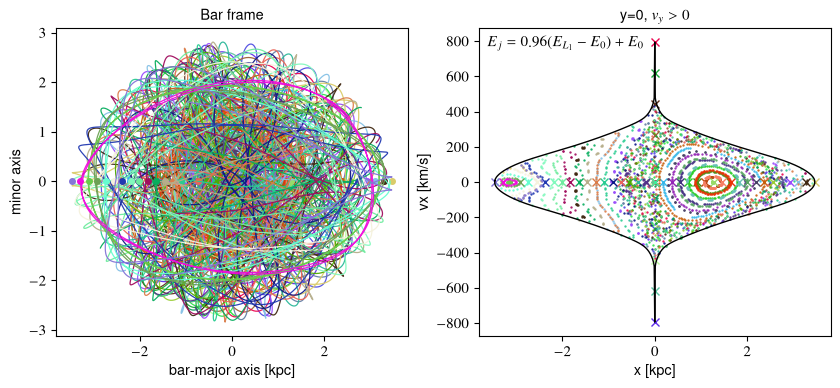